In [1]:
import statistics as stats

data = [10, 20, 20, 30, 40, 40, 40, 50]

# --- Central Tendency Measures ---
mean_value = stats.mean(data)
median_value = stats.median(data)


try:
    mode_value = stats.mode(data)
except stats.StatisticsError:
    mode_value = stats.multimode(data) 

# --- Measure of Dispersion ---
variance_value = stats.variance(data)          
std_dev_value = stats.stdev(data)              

# Output
print("Data:", data)
print("Mean:", mean_value)
print("Median:", median_value)
print("Mode:", mode_value)
print("Variance:", variance_value)
print("Standard Deviation:", std_dev_value)



Data: [10, 20, 20, 30, 40, 40, 40, 50]
Mean: 31.25
Median: 35.0
Mode: 40
Variance: 183.92857142857142
Standard Deviation: 13.562026818605375


In [2]:
import statistics as stats

data = [10, 20, 30, 40, 50]

print(stats.mean(data))
print(stats.median(data))
print(stats.variance(data))


30
30
250


In [3]:
import math

print(math.sqrt(16))
print(math.sin(math.pi / 2))
print(math.log(10, 10))


4.0
1.0
1.0


In [4]:
import numpy as np

arr = np.array([1, 2, 3, 4])
print(arr * 2)
print(np.mean(arr))


[2 4 6 8]
2.5


In [5]:
from scipy import stats

print(stats.norm.cdf(0))  
print(stats.ttest_1samp([2,3,4,5,6], 4))


0.5
TtestResult(statistic=0.0, pvalue=1.0, df=4)


In [6]:
pip install xgboost



  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/b8/90/f082b89dd74da8ca27f8a3c7b3e38fc8529a4a14eb2c5b0937c7d66aa922/xgboost-3.1.1-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/72.0 MB 2.0 MB/s eta 0:00:37
   ---------------------------------------- 0.5/72.0 MB 5.6 MB/s eta 0:00:13
   ---------------------------------------- 0.7/72.0 MB 6.3 MB/s eta 0:00:12
   ---------------------------------------- 0.7/72.0 MB 6.3 MB/s eta 0:00:12
    --------------------------------------- 1.6/72.0 MB 6.9 MB/s eta 0:00:11
   - -------------------------------------- 2.5/72.0 MB 8.2 MB/s eta 0:00:09
   - -------------------------------------- 2.7/72.0 MB 8.3 MB/s eta 0:00:09
   - -------------------------------------- 3.2/72.0 MB 8.3 MB/s eta 0:00:09
   - -------------------------------------- 3.6/72.0 MB 8.2 MB/s eta 0:00:09
   -- -------------------------

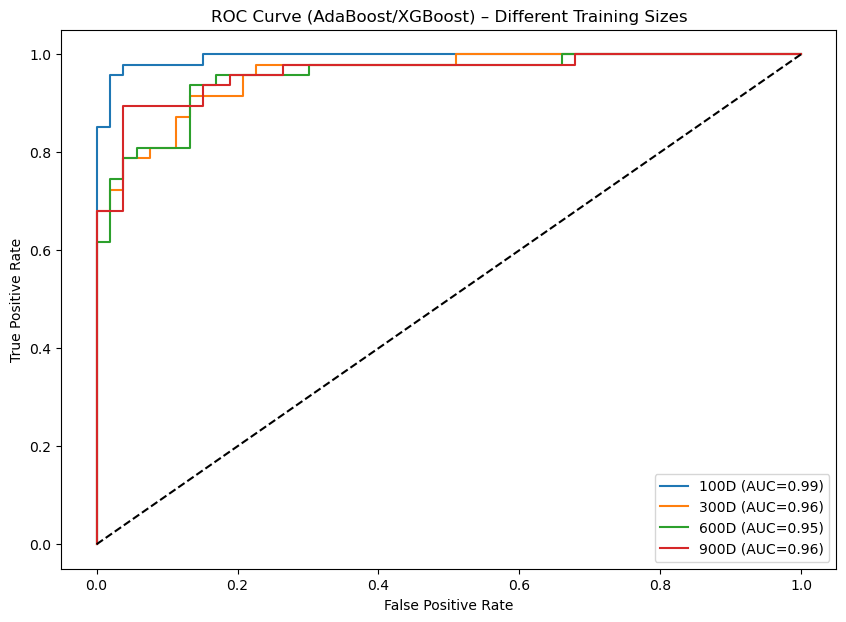

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier

train_data = pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\900D_heart_disease_dataset.csv")
test_data  = pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\100D_test_dataset.csv")

X_train_full = train_data.drop("target", axis=1)
y_train_full = train_data["target"]
X_test = test_data.drop("target", axis=1)
y_test = test_data["target"]


accuracy_list = []
precision_list = []
recall_list = []
auc_list = []

plt.figure(figsize=(10, 7))
for size in sizes:
    X_small = X_train_full[:size]
    y_small = y_train_full[:size]


    model = AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_small, y_small)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    auc_list.append(auc)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{size}D (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AdaBoost/XGBoost) – Different Training Sizes")
plt.legend()
plt.show()

